In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt




In [21]:
dataset = pd.read_csv('C:\\Users\\suraj\\OneDrive\\SELF\\sales_data.csv')
# dataset.head()
dataset

,Order_ID,Date,Region,Category,Product,Sales,Profit,Quantity
0,1001,2023-01-05,West,Technology,Laptop,55000.0,8000.0,2.0
1,1002,2023-01-10,East,Furniture,Chair,8000.0,NaN,4.0
2,1003,2023-01-15,South,Office Supplies,Notebook,500.0,100.0,NaN
3,1004,2023-02-01,North,Technology,Mobile,NaN,3000.0,3.0
4,1005,2023-02-05,NaN,Furniture,Table,15000.0,2000.0,2.0
5,1006,2023-02-12,East,Office Supplies,Pen,300.0,50.0,20.0
6,1007,2023-03-03,South,Technology,Tablet,12000.0,NaN,2.0
7,1008,2023-03-10,North,Furniture,Sofa,30000.0,5000.0,NaN
8,1009,2023-03-15,West,Office Supplies,File,700.0,150.0,8.0
9,1010,2023-04-01,East,Technology,Laptop,60000.0,9000.0,2.0


In [22]:
dataset.isnull().sum()

Order_ID    0
Date        0
Region      1
Category    1
Product     1
Sales       3
Profit      4
Quantity    3
dtype: int64

In [23]:
#HOW MANY ROWS AND COLUMNS ARE PRESENT?
dataset.shape

(20, 8)

In [25]:
#SHOW FIRST 5 ROWS
dataset.head(5)

,Order_ID,Date,Region,Category,Product,Sales,Profit,Quantity
0,1001,2023-01-05,West,Technology,Laptop,55000.0,8000.0,2.0
1,1002,2023-01-10,East,Furniture,Chair,8000.0,NaN,4.0
2,1003,2023-01-15,South,Office Supplies,Notebook,500.0,100.0,NaN
3,1004,2023-02-01,North,Technology,Mobile,NaN,3000.0,3.0
4,1005,2023-02-05,NaN,Furniture,Table,15000.0,2000.0,2.0


In [27]:
#CHECK DATA TYPE
dataset.dtypes

Order_ID      int64
Date         object
Region       object
Category     object
Product      object
Sales       float64
Profit      float64
Quantity    float64
dtype: object

In [28]:
#CONVERT DATE COLUMN
dataset['Date']=pd.to_datetime(df['Date'])
dataset

,Order_ID,Date,Region,Category,Product,Sales,Profit,Quantity
0,1001,2023-01-05,West,Technology,Laptop,55000.0,8000.0,2.0
1,1002,2023-01-10,East,Furniture,Chair,8000.0,NaN,4.0
2,1003,2023-01-15,South,Office Supplies,Notebook,500.0,100.0,NaN
3,1004,2023-02-01,North,Technology,Mobile,NaN,3000.0,3.0
4,1005,2023-02-05,NaN,Furniture,Table,15000.0,2000.0,2.0
5,1006,2023-02-12,East,Office Supplies,Pen,300.0,50.0,20.0
6,1007,2023-03-03,South,Technology,Tablet,12000.0,NaN,2.0
7,1008,2023-03-10,North,Furniture,Sofa,30000.0,5000.0,NaN
8,1009,2023-03-15,West,Office Supplies,File,700.0,150.0,8.0
9,1010,2023-04-01,East,Technology,Laptop,60000.0,9000.0,2.0


In [29]:
dataset.dtypes

Order_ID             int64
Date        datetime64[ns]
Region              object
Category            object
Product             object
Sales              float64
Profit             float64
Quantity           float64
dtype: object

In [30]:
#TOTAL SALES 
dataset['Sales'].sum()

np.float64(333700.0)

In [31]:
#AVRAGE PROFIT
dataset['Profit'].mean()

np.float64(3137.5)

In [32]:
dataset['Quantity'].sum()

np.float64(106.0)

In [33]:
dataset.groupby('Region')['Sales'].sum()

Region
East      86100.0
North     43000.0
South     79900.0
West     109700.0
Name: Sales, dtype: float64

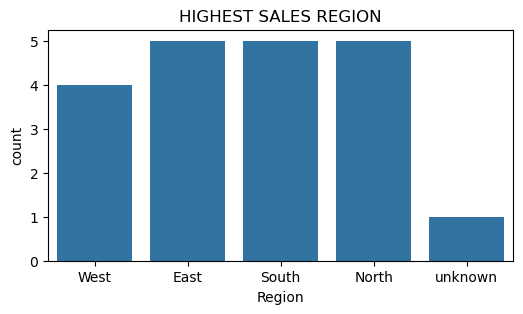

In [100]:
# HIGHEST SALES REGION
dataset.groupby('Region')['Sales'].sum().idxmax()
plt.figure(figsize=(6,3))
sns.countplot(x='Region',data=dataset)
plt.title('HIGHEST SALES REGION')

plt.show()


In [39]:
#LOWEST PROFIT REGIOIN
dataset.groupby('Region')['Profit'].sum().idxmin()

'East'

In [40]:
#CATEGORY-WISE SALES
dataset.groupby('Category')['Sales'].sum()

Category
Furniture          102000.0
Office Supplies      2700.0
Technology         220000.0
Name: Sales, dtype: float64

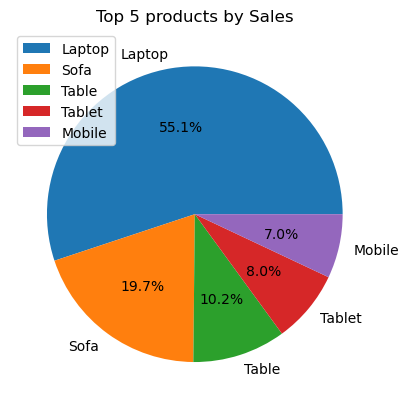

In [55]:
#MOST PROFITABLE CATEGORY
top_products=dataset.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(5)
plt.figure()
plt.pie(top_products,labels=top_products.index,autopct='%1.1f%%')
plt.title('Top 5 products by Sales')
plt.legend(loc=2)
plt.show()


In [57]:
#PRODUCT WITH THE HIGEST PEOFIT
dataset.groupby('Product')['Profit'].sum().idxmax()

'Laptop'

In [75]:

dataset['Sales'].fillna(dataset['Sales'].mean())

0     55000.000000
1      8000.000000
2       500.000000
3     19629.411765
4     15000.000000
5       300.000000
6     12000.000000
7     30000.000000
8       700.000000
9     60000.000000
10     9000.000000
11    19629.411765
12    22000.000000
13    17000.000000
14      400.000000
15    13000.000000
16    32000.000000
17      800.000000
18    58000.000000
19    19629.411765
Name: Sales, dtype: float64

In [83]:
#HANDLING MISSING VALUES
dataset.fillna({'Sales': dataset['Sales'].mean()}, inplace=True)
dataset.fillna({'Profit': 0}, inplace=True)
dataset.fillna({'Quantity': dataset['Quantity'].median()},inplace=True)
dataset.fillna({'Region':'unknown'},inplace=True)
dataset.fillna({'Category':'Other'},inplace=True)
dataset.fillna({'Product':'NOt Available'},inplace=True)
dataset


,Order_ID,Date,Region,Category,Product,Sales,Profit,Quantity
0,1001,2023-01-05,West,Technology,Laptop,55000.000000,8000.0,2.0
1,1002,2023-01-10,East,Furniture,Chair,8000.000000,0.0,4.0
2,1003,2023-01-15,South,Office Supplies,Notebook,500.000000,100.0,3.0
3,1004,2023-02-01,North,Technology,Mobile,19629.411765,3000.0,3.0
4,1005,2023-02-05,unknown,Furniture,Table,15000.000000,2000.0,2.0
5,1006,2023-02-12,East,Office Supplies,Pen,300.000000,50.0,20.0
6,1007,2023-03-03,South,Technology,Tablet,12000.000000,0.0,2.0
7,1008,2023-03-10,North,Furniture,Sofa,30000.000000,5000.0,3.0
8,1009,2023-03-15,West,Office Supplies,File,700.000000,150.0,8.0
9,1010,2023-04-01,East,Technology,Laptop,60000.000000,9000.0,2.0


In [93]:
#REGION WISE AGGREGATION
dataset.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'mean',
    'Quantity': 'sum'
})


,Sales,Profit,Quantity
Region,,,
East,86100.000000,1810.0,38.0
North,101888.235294,2424.0,24.0
South,79900.000000,2036.0,37.0
West,109700.000000,4212.5,14.0
unknown,15000.000000,2000.0,2.0


In [94]:
#FILTER DATA
dataset[dataset['Sales']>20000]


,Order_ID,Date,Region,Category,Product,Sales,Profit,Quantity
0,1001,2023-01-05,West,Technology,Laptop,55000.0,8000.0,2.0
7,1008,2023-03-10,North,Furniture,Sofa,30000.0,5000.0,3.0
9,1010,2023-04-01,East,Technology,Laptop,60000.0,9000.0,2.0
12,1013,2023-05-02,West,Technology,Mobile,22000.0,3200.0,3.0
16,1017,2023-06-07,West,Furniture,Sofa,32000.0,5500.0,1.0
18,1019,2023-07-03,South,Technology,Laptop,58000.0,8500.0,2.0


In [87]:
dataset[dataset['Profit']<1000]

,Order_ID,Date,Region,Category,Product,Sales,Profit,Quantity
1,1002,2023-01-10,East,Furniture,Chair,8000.000000,0.0,4.0
2,1003,2023-01-15,South,Office Supplies,Notebook,500.000000,100.0,3.0
5,1006,2023-02-12,East,Office Supplies,Pen,300.000000,50.0,20.0
6,1007,2023-03-03,South,Technology,Tablet,12000.000000,0.0,2.0
8,1009,2023-03-15,West,Office Supplies,File,700.000000,150.0,8.0
11,1012,2023-04-18,North,Office Supplies,Notebook,19629.411765,120.0,12.0
13,1014,2023-05-09,East,Furniture,Table,17000.000000,0.0,2.0
14,1015,2023-05-20,South,Office Supplies,NOt Available,400.000000,80.0,25.0
17,1018,2023-06-15,East,Office Supplies,File,800.000000,0.0,10.0


In [88]:
dataset.duplicated().sum()

np.int64(0)